   ## Ejercicio 1: Sistema de evaluación de crédito bancario

#### *Ficha PEAS*

| PEAS | Descripción |
| :--- | :--- |
| **Percepción (S)** | Ingreso mensual, monto solicitado, historial de morosidad del solicitante |
| **Acciones (A)** | Aprobar, aprobar con condiciones, rechazar |
| **Entorno (E)** | El sistema de evaluación crediticia del banco, con distintos perfiles de solicitantes |
| **Objetivo** | Aprobar créditos que el solicitante pueda pagar, minimizando el riesgo de impago |
| **Medida de desempeño (P)** | Proporción de créditos aprobados que se pagan correctamente, y proporción de rechazos justificados|

### *Justificación de las reglas*

Un banco si el monto es alto en terminos relativos al ingreso del solicitante, por eso se calcula la relación monto solicitado / ingreso mensual. Una relación baja indica que la cuota probable será manejable frente al ingreso, mientras que una relación alta implica mayor riesgo de impago. El historial moroso se usa para exigir condiciones adicionales o rechazar en casos limite donde sin ese historial se habría aprobado.

### *Código*

- [ ] Si la relacion es menor a 0.3 y no tiene historial moroso ⇒ riesgo bajo, aprobar
- [ ] Si la relacion es menor a 0.3 pero tiene historial moroso ⇒ Aprobar con condiciones
- [ ] Relación entre 0.3 y 0.5, sin historial ⇒ Aprobar con condiciones
- [ ] Caso contrario ⇒ rechazar

In [1]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    relacion = monto_solicitado / ingreso_mensual
    if relacion <= 0.3 and not tiene_historial_moroso:
        return "aprobar", "relacion monto/ingreso baja y sin historial moroso"
    elif relacion <= 0.3 and tiene_historial_moroso:
        return "aprobar con condiciones", "relacion baja pero con historial moroso"
    elif relacion <= 0.5 and not tiene_historial_moroso:
        return "aprobar con condiciones", "relacion moderada, sin historial moroso"
    else:
        return "rechazar", "relacion monto/ingreso mayor a 0.5 o historial moroso con relacion elevada"

### Simulación y pruebas

In [2]:
casos = [
    (3000, 500, False),
    (3000, 500, True),
    (3000, 1200, False),
    (3000, 1200, True),
    (2000, 1000, False),
    (2000, 2500, False),
]

for ingreso, monto, historial in casos:
    accion, motivo = agente_credito(ingreso, monto, historial)
    print(f"Ingreso: {ingreso}, Monto: {monto}, Moroso: {historial} -> {accion} ({motivo})")

Ingreso: 3000, Monto: 500, Moroso: False -> aprobar (relacion monto/ingreso baja y sin historial moroso)
Ingreso: 3000, Monto: 500, Moroso: True -> aprobar con condiciones (relacion baja pero con historial moroso)
Ingreso: 3000, Monto: 1200, Moroso: False -> aprobar con condiciones (relacion moderada, sin historial moroso)
Ingreso: 3000, Monto: 1200, Moroso: True -> rechazar (relacion monto/ingreso mayor a 0.5 o historial moroso con relacion elevada)
Ingreso: 2000, Monto: 1000, Moroso: False -> aprobar con condiciones (relacion moderada, sin historial moroso)
Ingreso: 2000, Monto: 2500, Moroso: False -> rechazar (relacion monto/ingreso mayor a 0.5 o historial moroso con relacion elevada)


## *Visualización con 200 solicitudes aleatorias*


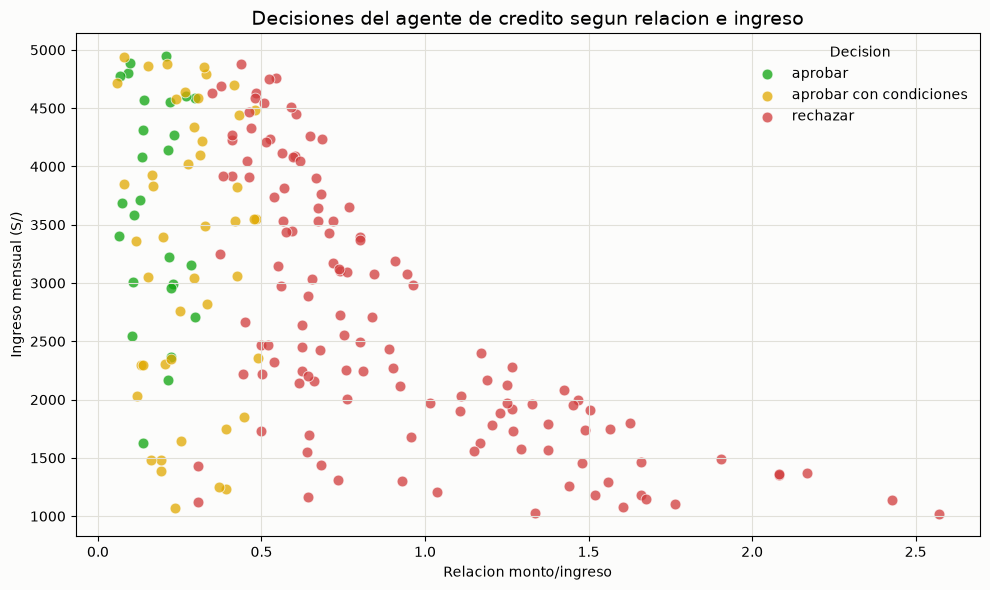

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200
ingresos = np.random.uniform(1000, 5000, n)
montos = np.random.uniform(200, 3000, n)
historiales = np.random.choice([True, False], n)

resultados = [agente_credito(ingresos[i], montos[i], historiales[i]) for i in range(n)]
acciones = [r[0] for r in resultados]
relaciones = montos / ingresos

colores = {"aprobar": "#0ca30c", "aprobar con condiciones": "#e0a800", "rechazar": "#d03b3b"}

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

for accion in colores:
    idx = [i for i in range(n) if acciones[i] == accion]
    ax.scatter(np.array(relaciones)[idx], ingresos[idx],
               c=colores[accion], label=accion, s=60, alpha=0.75,
               edgecolors="white", linewidths=0.6)

ax.set_title("Decisiones del agente de credito segun relacion e ingreso", fontsize=14)
ax.set_xlabel("Relacion monto/ingreso")
ax.set_ylabel("Ingreso mensual (S/)")
ax.legend(title="Decision", frameon=False)
ax.grid(True, color="#e1e0d9", linewidth=0.8)
plt.tight_layout()
plt.show()

Nota. La grafica muestra los 200 puntos coloreados segun la decision tomada por el agente.